In [1]:
import sys
import os
import pandas as pd
import numpy as np

from src.data_loader import load_data
from src.solver_LAM import solve_lam_stqp
from src.solver_Markowitz import solve_markowitz
from src.visualize_portfolio import visualize_portfolio_performance
from src.efficient_frontier import compute_efficient_frontier_parallel, plot_efficient_frontier
from src.calculate_sharpe_ratio import calculate_portfolio_sharpe
from src.efficient_frontier_comparison import compute_efficient_frontier_lam, compute_efficient_frontier_markowitz, plot_efficient_frontier_comparison

## **パラメータ設定**

In [2]:
DATA_FILE = 'data/topix-large500-after.csv'
START_DATE = '2018-01-01'
END_DATE = '2021-12-31'

## **データ読み込み**

In [3]:
# 1. Load Data
mu, sigma, assets, df = load_data(DATA_FILE, start_date=START_DATE, end_date=END_DATE)

Loading data from data/topix-large500-after.csv...
Data loaded successfully. 497 assets.
Optimization period: 2018-01-09 to 2021-12-30 (972 periods)


## **効率的フロンティアの可視化**

Starting LAM-STQP parallel frontier (50 pts)...
[LAM] Progress: 50/50 (100.0%)
Finished LAM-STQP frontier in 174.71s.
Starting Markowitz parallel frontier (50 pts)...
[MK] Progress: 50/50 (100.0%)
Finished Markowitz frontier in 381.32s.
Efficient frontier comparison saved to: output_final\efficient_frontier_comparison.png


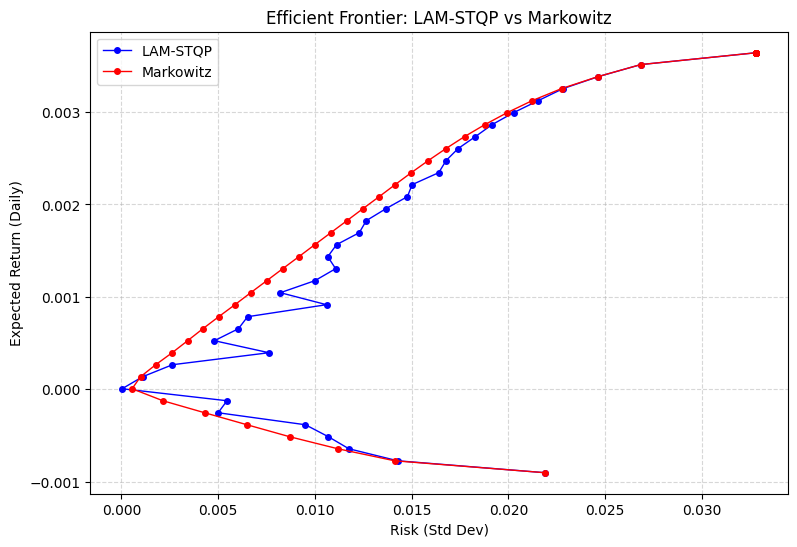

In [4]:
frontier_lam = compute_efficient_frontier_lam(
    mu, sigma,
    n_points=50,
    k_max=10,
    min_weight=0.0, max_weight=1.0,
    penalty_m=1e7,
    max_workers=None
)

frontier_mkw = compute_efficient_frontier_markowitz(
    mu, sigma,
    n_points=50,
    min_weight=0.0, max_weight=1.0,
    penalty_m=1e7,
    max_workers=None
)

plot_efficient_frontier_comparison(frontier_lam, frontier_mkw)

## **最適化問題の求解**
- パラメータ推定期間: 2018-01-01 ~ 2021-12-31

In [16]:
TARGET_RETURN = 0.0005  # 0.05% daily return (approx 12% annual)
MIN_WEIGHT = 0          # Min 1% per asset
MAX_WEIGHT = 1.0        # Max 100% per asset
PENALTY_M = 1e7         # Penalty for return deviation

### **LAMモデル**

In [17]:
CARDINALITY_K = 10      # Max 10 assets
print("=== Portfolio Optimization (LAM/StQP) ===")
print(f"Target Return: {TARGET_RETURN:.6f}")
print(f"Cardinality K: {CARDINALITY_K}")
print(f"Penalty M: {PENALTY_M}")

result_LAM = solve_lam_stqp(
    mu, sigma, 
    target_return=TARGET_RETURN,
    k_max=CARDINALITY_K,
    min_weight=MIN_WEIGHT,
    max_weight=MAX_WEIGHT,
    penalty_m=PENALTY_M
)

print("\n=== Optimization Results ===")
print(f"Objective Value: {result_LAM['objective']:.6f}")
print(f"Portfolio Return: {result_LAM['return']:.6f}")
print(f"Portfolio Risk (Std): {result_LAM['risk']:.6f}")
print(f"Number of Assets: {len(result_LAM['assets'])}")
print("\nSelected Assets and Weights:")
print(result_LAM['weights'].sort_values(ascending=False))

result_LAM['weights'].to_csv('output_final/optimization_result_LAM_K10.csv', header=['Weight'])
print("\nResults saved to optimization_result_LAM_K10.csv")

=== Portfolio Optimization (LAM/StQP) ===
Target Return: 0.000500
Cardinality K: 10
Penalty M: 10000000.0
Starting optimization with K=10, Target=0.0005, M=10000000.0
  Step k=1/10...
    New best found at k=1: Obj=0.000425
  Step k=2/10...
    New best found at k=2: Obj=0.000224
  Step k=3/10...
    New best found at k=3: Obj=0.000199
  Step k=4/10...
    New best found at k=4: Obj=0.000174
  Step k=5/10...
    New best found at k=5: Obj=0.000102
  Step k=6/10...
    New best found at k=6: Obj=0.000052
  Step k=7/10...
    New best found at k=7: Obj=0.000031
  Step k=8/10...
    New best found at k=8: Obj=0.000025
  Step k=9/10...
    New best found at k=9: Obj=0.000019
  Step k=10/10...
    New best found at k=10: Obj=0.000016

=== Optimization Results ===
Objective Value: 0.000016
Portfolio Return: 0.000500
Portfolio Risk (Std): 0.004005
Number of Assets: 10

Selected Assets and Weights:
8729    0.666495
3038    0.037115
6920    0.037112
6532    0.037072
4483    0.037068
4194    0.0

In [18]:
CARDINALITY_K = 5       # Max 05 assets
print("=== Portfolio Optimization (LAM/StQP) ===")
print(f"Target Return: {TARGET_RETURN:.6f}")
print(f"Cardinality K: {CARDINALITY_K}")
print(f"Penalty M: {PENALTY_M}")

result_LAM = solve_lam_stqp(
    mu, sigma, 
    target_return=TARGET_RETURN,
    k_max=CARDINALITY_K,
    min_weight=MIN_WEIGHT,
    max_weight=MAX_WEIGHT,
    penalty_m=PENALTY_M
)

print("\n=== Optimization Results ===")
print(f"Objective Value: {result_LAM['objective']:.6f}")
print(f"Portfolio Return: {result_LAM['return']:.6f}")
print(f"Portfolio Risk (Std): {result_LAM['risk']:.6f}")
print(f"Number of Assets: {len(result_LAM['assets'])}")
print("\nSelected Assets and Weights:")
print(result_LAM['weights'].sort_values(ascending=False))

result_LAM['weights'].to_csv('output_final/optimization_result_LAM_K05.csv', header=['Weight'])
print("\nResults saved to optimization_result_LAM_K05.csv")

=== Portfolio Optimization (LAM/StQP) ===
Target Return: 0.000500
Cardinality K: 5
Penalty M: 10000000.0
Starting optimization with K=5, Target=0.0005, M=10000000.0
  Step k=1/5...
    New best found at k=1: Obj=0.000425
  Step k=2/5...
    New best found at k=2: Obj=0.000224
  Step k=3/5...
    New best found at k=3: Obj=0.000199
  Step k=4/5...
    New best found at k=4: Obj=0.000174
  Step k=5/5...
    New best found at k=5: Obj=0.000102

=== Optimization Results ===
Objective Value: 0.000102
Portfolio Return: 0.000500
Portfolio Risk (Std): 0.010103
Number of Assets: 5

Selected Assets and Weights:
4194    0.482394
3360    0.205187
8136    0.167800
6754    0.125400
4483    0.019220
dtype: float64

Results saved to optimization_result_LAM_K05.csv


### **Markowitzモデル**

In [19]:
print("=== Portfolio Optimization (LAM/StQP) ===")
print(f"Target Return: {TARGET_RETURN:.6f}")
print(f"Penalty M: {PENALTY_M}")

result_Markowitz = solve_markowitz(
    mu, sigma, 
    target_return=TARGET_RETURN,
    min_weight=MIN_WEIGHT,
    max_weight=MAX_WEIGHT
)

print("\n=== Optimization Results ===")
print(f"Objective Value: {result_Markowitz['objective']:.6f}")
print(f"Portfolio Return: {result_Markowitz['return']:.6f}")
print(f"Portfolio Risk (Std): {result_Markowitz['risk']:.6f}")
print(f"Number of Assets: {len(result_Markowitz['assets'])}")
print("\nSelected Assets and Weights:")
print(result_Markowitz['weights'].sort_values(ascending=False))

result_Markowitz['weights'].to_csv('output_final/optimization_result_Markowitz.csv', header=['Weight'])
print("\nResults saved to optimization_result_Markowitz.csv")

=== Portfolio Optimization (LAM/StQP) ===
Target Return: 0.000500
Penalty M: 10000000.0

=== Optimization Results ===
Objective Value: 0.000010
Portfolio Return: 0.000481
Portfolio Risk (Std): 0.003093
Number of Assets: 28

Selected Assets and Weights:
9023    0.064759
5830    0.064759
5016    0.064759
5832    0.064759
5831    0.064759
8729    0.064759
6526    0.064759
5838    0.064759
5844    0.064759
6525    0.064759
9147    0.064759
5076    0.056536
3038    0.051036
6920    0.032396
4194    0.028495
7337    0.020092
9468    0.019370
6532    0.017807
4483    0.012275
3923    0.012151
9101    0.009499
3563    0.008612
3774    0.006888
3697    0.005005
6951    0.004427
4887    0.001910
4568    0.001004
4901    0.000145
dtype: float64

Results saved to optimization_result_Markowitz.csv


## **Sharpe ratioの算出**
- パフォーマンス算出期間: 2018-01-01 ~ 2024-12-31

In [38]:
PRICE_CSV_PATH = 'data/topix-large500-after.csv'
WEIGHT_FILE_LAM_K10 = "output_final/optimization_result_LAM_K10.csv"
WEIGHT_FILE_LAM_K05 = "output_final/optimization_result_LAM_K05.csv"
WEIGHT_FILE_MARKOWITZ = "output_final/optimization_result_Markowitz.csv"
risk_free_rate = 0

sharpe_ratio_LAM_K10 = calculate_portfolio_sharpe(
    price_csv_path=PRICE_CSV_PATH,
    weight_csv_path=WEIGHT_FILE_LAM_K10,
    start_date=START_DATE,
    end_date=END_DATE,
    risk_free_rate=risk_free_rate
)

sharpe_ratio_LAM_K05 = calculate_portfolio_sharpe(
    price_csv_path=PRICE_CSV_PATH,
    weight_csv_path=WEIGHT_FILE_LAM_K05,
    start_date=START_DATE,
    end_date=END_DATE,
    risk_free_rate=risk_free_rate
)

sharpe_ratio_markowitz = calculate_portfolio_sharpe(
    price_csv_path=PRICE_CSV_PATH,
    weight_csv_path=WEIGHT_FILE_MARKOWITZ,
    start_date=START_DATE,
    end_date=END_DATE,
    risk_free_rate=risk_free_rate
)

sharpe_ratio_df = pd.DataFrame([
    {"case": "LAM_K10", **sharpe_ratio_LAM_K10},
    {"case": "LAM_K05", **sharpe_ratio_LAM_K05},
    {"case": "Markowitz", **sharpe_ratio_markowitz}
])

sharpe_ratio_df.to_csv("output_final/sharpe_ratio.csv", index=False)
sharpe_ratio_df

Loading data from data/topix-large500-after.csv...
Data loaded successfully. 497 assets.
Optimization period: 2018-01-09 to 2021-12-30 (972 periods)
Loading data from data/topix-large500-after.csv...
Data loaded successfully. 497 assets.
Optimization period: 2018-01-09 to 2021-12-30 (972 periods)
Loading data from data/topix-large500-after.csv...
Data loaded successfully. 497 assets.
Optimization period: 2018-01-09 to 2021-12-30 (972 periods)


,case,annual_return,annual_risk,sharpe_ratio
0,LAM_K10,0.075352,0.086721,0.868904
1,LAM_K05,0.156454,0.236652,0.661112
2,Markowitz,0.160562,0.125871,1.275613


## **ポートフォリオ+指数の累積収益率**

Loading data from data/topix-large500-after.csv...
Data loaded successfully. 497 assets.
Optimization period: 2018-01-09 to 2021-12-30 (972 periods)
Loaded market index and plotted TOPIX / Nikkei225.
Saved figure to: output_final\portfolio_performance.png


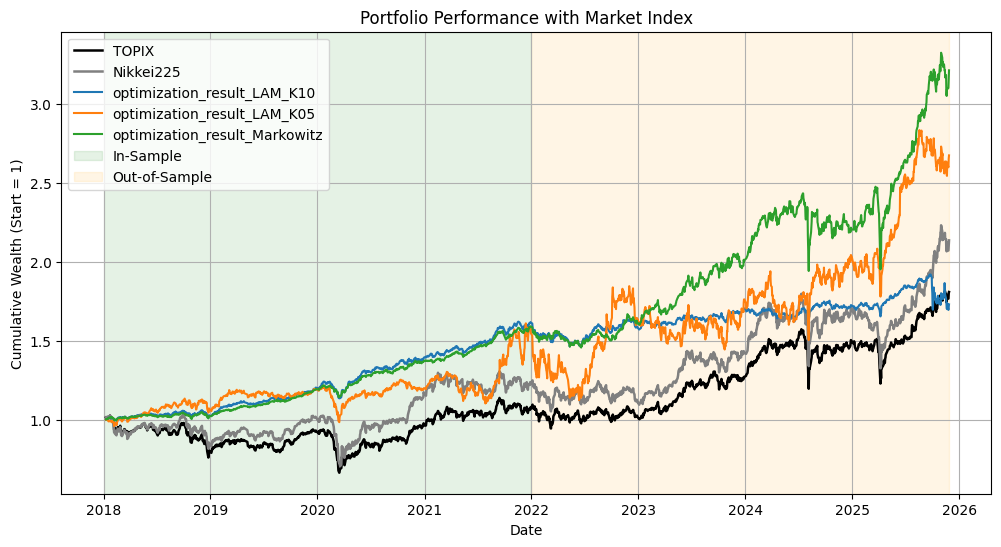

In [37]:
visualize_portfolio_performance(
    start_date = START_DATE,
    end_date = END_DATE,
    price_csv_path="data/topix-large500-after.csv",
    weight_csv_paths=[
        "output_final/optimization_result_LAM_K10.csv", 
        "output_final/optimization_result_LAM_K05.csv",
        "output_final/optimization_result_Markowitz.csv"
        ],
    market_csv_path="data/marketindex.csv",
    output_dir="output_final",
    output_filename="portfolio_performance.png"
)